# Linear Motion Deblurring

This notebook is developed based on: 
> Hansen, P. C., Nagy, J. G., & O'Leary, D. P. (2006). Deblurring images: Matrices, spectra, and filtering. SIAM, Society for Industrial and Applied Mathematics. https://doi.org/10.1137/1.9780898718874

In [1]:
import os
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt

----------
### Convert An Image File Into Normalized NumPy Array using Pillow
> Pillow Documentation (https://pillow.readthedocs.io/en/stable/index.html)

In [2]:
##############################################################################
# Note: .convert('L') is to make sure the image mode is in grayscale 
#       as common photo editors tend to use RGB even for black & white images.
##############################################################################

def convert_img_to_norm_np_arr(input_location, grayscale=False):
    """Convert given image to normalized pixel values from [0,255] to [0,1] in Numpy array."""
    
    img = Image.open(input_location).convert('L') if grayscale else Image.open(input_location)
    return np.array(img).astype(np.float64) / 255

In [3]:
# A function to save images
def save_img(img_arr, output_name, grayscale=False, output_location='./motion_deblur_img/output/'):
    """Save the given pixel array as an image file."""
    
    os.makedirs(output_location, exist_ok=True)
    img = Image.fromarray(np.clip(img_arr * 255, 0, 255).astype(np.uint8))
    img = img.convert('L') if grayscale else img
    img.save(os.path.join(output_location, output_name))

----------
### Build Point Spread Function (PSF) for horizontal/vertical motion blur
> Hansen et al.(2006), Chapter 3.3 - Obtaining the PSF (p.25)

In [4]:
def build_horizontal_motion_psf(length, img_shape):
    """Build horizontal motion psf with padding zeros."""
    
    psf = np.zeros(img_shape)
    psf[0, :length] = 1 / length
    return psf

def build_vertical_motion_psf(length, img_shape):
    """Build vertical motion psf with padding zeros."""
    
    psf = np.zeros(img_shape)
    psf[:length, 0] = 1 / length
    return psf

----------
### Compute a blurred image from the original image
> Hansen et al.(2006), Chapter 4.2.2 - Computations with BCCB Matrices (p.44)

In [5]:
def compute_blurred_img(psf, orig_img, noise_amount=0.01):
    """Return the blurred image array by given psf."""
    
    eigen_val_A = np.fft.fft2(psf)
    blurred = np.real(np.fft.ifft2(eigen_val_A * np.fft.fft2(orig_img)))
    noise = noise_amount * np.random.randn(*orig_img.shape)
    
    return blurred + noise

----------
### Compute a naive solution from the blurred image
> Hansen et al.(2006), Chapter 4.2.2 - Computations with BCCB Matrices (p.44)

In [6]:
def compute_naive_solution(psf, blurred_img):
    eigen_val_A = np.fft.fft2(psf)
    return np.real(np.fft.ifft2(np.fft.fft2(blurred_img) / eigen_val_A))

----------
### Compute Truncated SVD (Singular Value Decomposition)
> **Hansen et al.(2006)**
> - Chapter 5.1 - Introduction to Spectral Filtering (p.55-56)
> - Chapter 6.2 - Implementation of Filtering Methods (p.74-75)

In [7]:
def compute_tsvd(psf, blurred_img, tol):
    eigen_val_A = np.fft.fft2(psf)
    tsvd_filter = np.abs(eigen_val_A) >= tol
    safe_eigen = np.where(tsvd_filter, eigen_val_A, 1)
    filtered = np.where(tsvd_filter, (1 / safe_eigen), 0)
    
    return np.real(np.fft.ifft2(np.fft.fft2(blurred_img) * filtered))

----------
### Compute Tikhonov Regularization
> **Hansen et al.(2006)**
> - Chapter 6.1 - Two Important Methods (p.72-73)
> - Chapter 6.2 - Implementation of Filtering Methods (p.74-75)

In [8]:
def compute_tikhonov(psf, blurred_img, alpha):
    eigen_val_A = np.fft.fft2(psf)
    tikhonov_filter = (np.abs(eigen_val_A) ** 2) / ( (np.abs(eigen_val_A) ** 2) + (alpha ** 2) )
    safe_eigen = np.where(np.abs(eigen_val_A) > 0, eigen_val_A, 1)
    filtered = np.where(np.abs(eigen_val_A) > 0, tikhonov_filter / safe_eigen, 0)
    
    return np.real(np.fft.ifft2(np.fft.fft2(blurred_img) * filtered))

def get_alpha_min_max(psf):
    eigen_val_A = np.fft.fft2(psf)
    alpha_min = np.min(np.abs(eigen_val_A))
    alpha_max = np.max(np.abs(eigen_val_A))
    
    return (alpha_min, alpha_max)

----------
### Build PSF for Linear Motion Blur at Various Angles

In [9]:
def get_pixel_pos_for_angled_linear_motion(length, angle_deg):
    """Return a list of pixel coordinates for a motion blur line of given length and angle.
    All the position is shifted to positive axis to align it for psf."""
    
    len_list = np.linspace(0, length - 1, num=(length * 2))
    pos_set = set()
    shifted_rad = np.radians(angle_deg) + (np.pi / 2)

    for l in len_list:
        x_pos = abs(round( np.cos(shifted_rad) * l ))
        y_pos = abs(round( np.sin(shifted_rad) * l ))
        pos_set.add((x_pos, y_pos))
        
    return list(pos_set)
    
def build_linear_motion_psf(length, angle_deg, img_shape):
    """Build angled linear motion psf with padding zeros."""
    
    psf = np.zeros(img_shape)
    positions = get_pixel_pos_for_angled_linear_motion(length, angle_deg)
    pos_count = len(positions)
    for pos in positions:
        psf[*pos] = 1 / pos_count
        
    return psf

def transform_img(angle_deg, orig_img):
    """Transform the image so the motion blur aligns with the given angle for psf computation."""
    
    deg = (angle_deg % 360)
    if 0 <= deg <= 90:
        return np.flipud(orig_img)
    elif 90 < deg <= 180:
        return np.fliplr(np.flipud(orig_img))
    elif 180 < deg <= 270:
        return np.fliplr(orig_img)
    
    return orig_img

def compute_linear_motion_blur(length, angle_deg, orig_img, noise_amount=0.01):
    """Return the linear motion blurred frequency domain array by the given length and angle."""
    
    trans_img = transform_img(angle_deg, orig_img)
    psf = build_linear_motion_psf(length, angle_deg, trans_img.shape)
    
    eigen_val_A = np.fft.fft2(psf)
    blurred = np.real(np.fft.ifft2(eigen_val_A * np.fft.fft2(trans_img)))
    noise = noise_amount * np.random.randn(*trans_img.shape)
    
    result_img = transform_img(angle_deg, (blurred + noise))
    return result_img

def plot_l_curve_linear_motion(deblur_func, length, angle_deg, blurred_img, min_val, max_val, title, at_vals):
    trans_img = transform_img(angle_deg, blurred_img)
    psf = build_linear_motion_psf(length, angle_deg, trans_img.shape)
    plot_l_curve(deblur_func, psf, trans_img, min_val, max_val, title, at_vals)
    
def compute_linear_motion_deblur(deblur_func, length, angle_deg, blurred_img, alpha):
    """Return deblurred frequency domain array by the given length and angle."""
    
    trans_img = transform_img(angle_deg, blurred_img)
    psf = build_linear_motion_psf(length, angle_deg, trans_img.shape)
    
    deblurred = deblur_func(psf, trans_img, alpha)
    result_img = transform_img(angle_deg, deblurred)
    
    return result_img
    

----------
### Visualization

In [10]:
# plot L-curve (log-log plot) to find optimal value

def get_solution_residual_norms(deblur_func, psf, blurred_img, at_val):
    eigen_val_A = np.fft.fft2(psf)
    soln = deblur_func(psf, blurred_img, at_val)
    solution_norm = np.linalg.norm(soln)
    residual_norm = np.linalg.norm(blurred_img - np.real(np.fft.ifft2(eigen_val_A * np.fft.fft2(soln))))
    
    return solution_norm, residual_norm

def plot_l_curve(deblur_func, psf, blurred_img, min_val, max_val, title, at_vals):
    """Plot log-log L-curve for the given deblurring function.
    
    Parameters:
    deblur_func (function): deblurring method (e.g. compute_tikhonov, compute_tsvd)
    psf (ndarray): point spread function array
    blurred_img (ndarray): blurred image array
    min_val (float): start point of x-axis
    max_val (float): end point of x-axis
    title (str): plot title
    at_vals (list): alpha/tol values to specifically annotate on the L-curve
    """
    _, plot = plt.subplots(figsize=(4,3))
    linvals = np.linspace(min_val, max_val, num=100)
    solution_norms = []
    residual_norms = []
    
    for val in linvals:
        solution_norm, residual_norm = get_solution_residual_norms(deblur_func, psf, blurred_img, val)
        solution_norms.append(solution_norm)
        residual_norms.append(residual_norm)

    plot.loglog(residual_norms, solution_norms, '-o', markersize=3)

    # plot point for the given specific at_vals
    for val in at_vals:
        solution_norm, residual_norm = get_solution_residual_norms(deblur_func, psf, blurred_img, val)
        plot.plot(residual_norm, solution_norm, 'o')
        plot.annotate(f'{val:.3f}', (residual_norm, solution_norm), xytext=(5,0), textcoords='offset points', fontsize=8)
        
    plt.xlabel("Residual Norm ||b-Ax||")
    plt.ylabel("solution Norm ||x||")
    plt.title(title)
    plt.show()

In [11]:
def plot_comparison(arr_list, label_list, row, col, figsize=(12,4), cmap=None):
    """Plot images side by side for comparison."""
    
    _, sub = plt.subplots(row, col, figsize=figsize)
    sub = sub.flatten()
    [s.axis('off') for s in sub]
    
    for sub_idx in range(len(arr_list)):
        sub[sub_idx].imshow(arr_list[sub_idx], cmap=cmap)
        sub[sub_idx].set_title(label_list[sub_idx], y=-0.1)
        
    plt.subplots_adjust(wspace=0.1, hspace=0)
    plt.show()

----------
----------
## Example 1
> Image Credit: [Arturo Anez from Pixabay](https://pixabay.com/photos/cat-pet-animal-nature-domestic-cat-9569386/)
### Horizontal/Vertical Motion Blur with a Grayscale Image

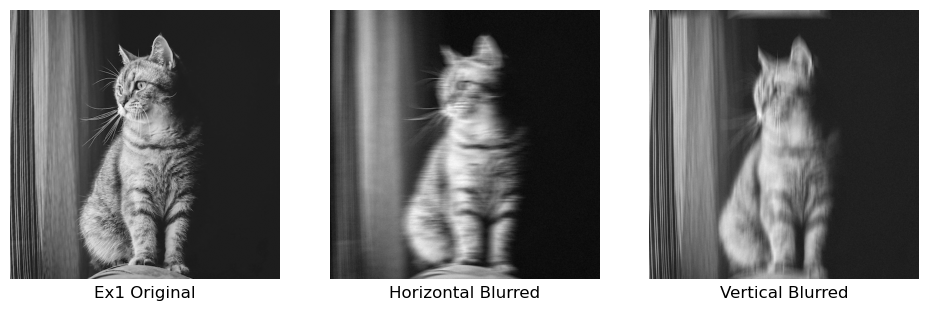

In [12]:
ex1_gray_arr = convert_img_to_norm_np_arr('./motion_deblur_img/input/Image_by_Arturo_Anez_from_Pixabay.jpg',
                                          grayscale=True)
length = 20
ex1_h_psf = build_horizontal_motion_psf(length, ex1_gray_arr.shape)
ex1_h_blurred = compute_blurred_img(ex1_h_psf, ex1_gray_arr)
ex1_v_psf = build_vertical_motion_psf(length, ex1_gray_arr.shape)
ex1_v_blurred = compute_blurred_img(ex1_v_psf, ex1_gray_arr)

plot_comparison([ex1_gray_arr, ex1_h_blurred, ex1_v_blurred],
          ['Ex1 Original', 'Horizontal Blurred', 'Vertical Blurred'],
          1, 3, figsize=(12, 3.5), cmap='gray')

save_img(ex1_gray_arr, 'ex1_gray.jpg', grayscale=True)
save_img(ex1_h_blurred, 'ex1_horizontal_blurred.jpg', grayscale=True)
save_img(ex1_v_blurred, 'ex1_vertical_blurred.jpg', grayscale=True)

### Deblur Method Comparison with Horizontal Blurred Image
#### Naive Solutions

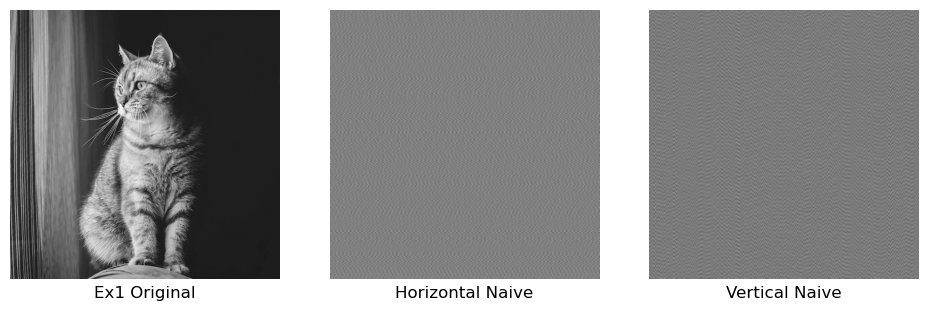

In [13]:
ex1_h_naive = compute_naive_solution(ex1_h_psf, ex1_h_blurred)
ex1_v_naive = compute_naive_solution(ex1_v_psf, ex1_v_blurred)

plot_comparison([ex1_gray_arr, ex1_h_naive, ex1_v_naive],
          ['Ex1 Original', 'Horizontal Naive', 'Vertical Naive'],
          1, 3, figsize=(12, 3.5), cmap='gray')

#### Truncated SVD and Tikhonov

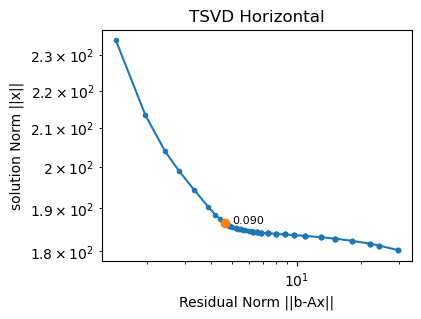

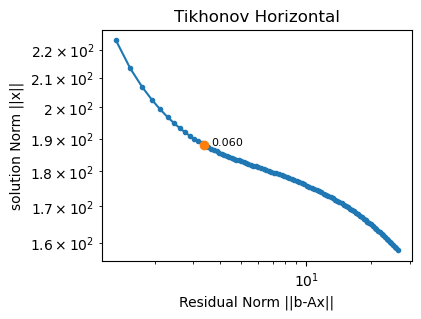

In [14]:
min_max = get_alpha_min_max(ex1_h_psf)
ex1_h_tsvd_tol = 0.090
ex1_h_tikhonov_alpha = 0.060

plot_l_curve(compute_tsvd, ex1_h_psf, ex1_h_blurred, 
             min_max[0]+0.01, min_max[1]-0.1, 'TSVD Horizontal', [ex1_h_tsvd_tol])
plot_l_curve(compute_tikhonov, ex1_h_psf, ex1_h_blurred, 
             min_max[0]+0.01, min_max[1]-0.6, 'Tikhonov Horizontal', [ex1_h_tikhonov_alpha])

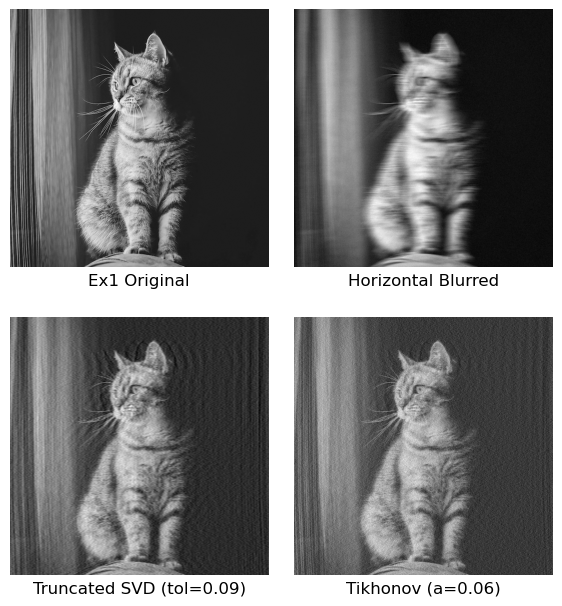

In [15]:
ex1_h_tsvd = compute_tsvd(ex1_h_psf, ex1_h_blurred, ex1_h_tsvd_tol)
ex1_h_tikhonov = compute_tikhonov(ex1_h_psf, ex1_h_blurred, ex1_h_tikhonov_alpha)

plot_comparison([ex1_gray_arr, ex1_h_blurred, ex1_h_tsvd, ex1_h_tikhonov],
          ['Ex1 Original', 'Horizontal Blurred', f'Truncated SVD (tol={ex1_h_tsvd_tol})', f'Tikhonov (a={ex1_h_tikhonov_alpha})'],
          2, 2, figsize=(7, 8), cmap='gray')

save_img(ex1_h_tikhonov, 'ex1_horizontal_tikhonov.jpg', grayscale=True)

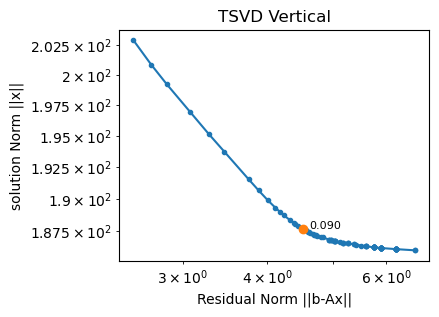

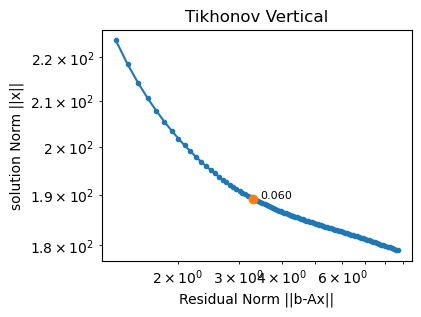

In [16]:
min_max = get_alpha_min_max(ex1_v_psf)
ex1_v_tsvd_tol = 0.090
ex1_v_tikhonov_alpha = 0.060

plot_l_curve(compute_tsvd, ex1_v_psf, ex1_v_blurred, 
             min_max[0]+0.03, min_max[1]-0.6, 'TSVD Vertical', [ex1_v_tsvd_tol])
plot_l_curve(compute_tikhonov, ex1_v_psf, ex1_v_blurred, 
             min_max[0]+0.01, min_max[1]-0.8, 'Tikhonov Vertical', [ex1_v_tikhonov_alpha])

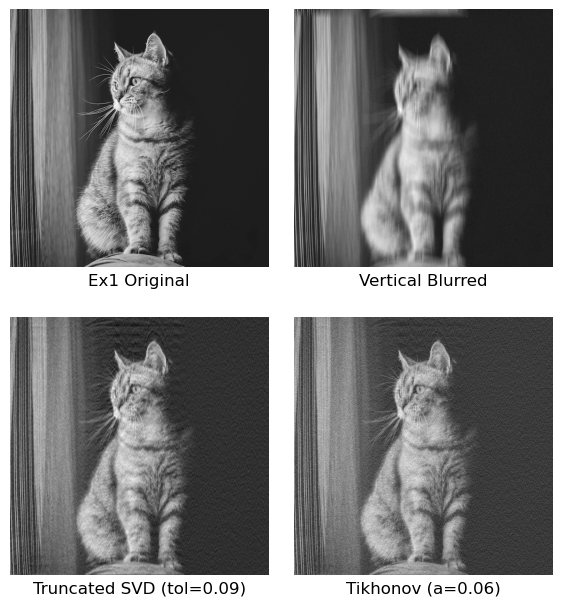

In [17]:
ex1_v_naive = compute_naive_solution(ex1_v_psf, ex1_v_blurred)
ex1_v_tsvd = compute_tsvd(ex1_v_psf, ex1_v_blurred, ex1_v_tsvd_tol)
ex1_v_tikhonov = compute_tikhonov(ex1_v_psf, ex1_v_blurred, ex1_v_tikhonov_alpha)

plot_comparison([ex1_gray_arr, ex1_v_blurred, ex1_v_tsvd, ex1_v_tikhonov],
          ['Ex1 Original', 'Vertical Blurred', f'Truncated SVD (tol={ex1_v_tsvd_tol})', f'Tikhonov (a={ex1_v_tikhonov_alpha})'],
          2, 2, figsize=(7, 8), cmap='gray')

save_img(ex1_v_tikhonov, 'ex1_vertical_tikhonov.jpg', grayscale=True)

----------
----------
## Example 2
> Image Credit: [Pavel_from_Pixabay](https://pixabay.com/photos/cat-kitten-tree-curious-tabby-1647775/)

### Linear Motion Blur at Various Angles with a Grayscale Image

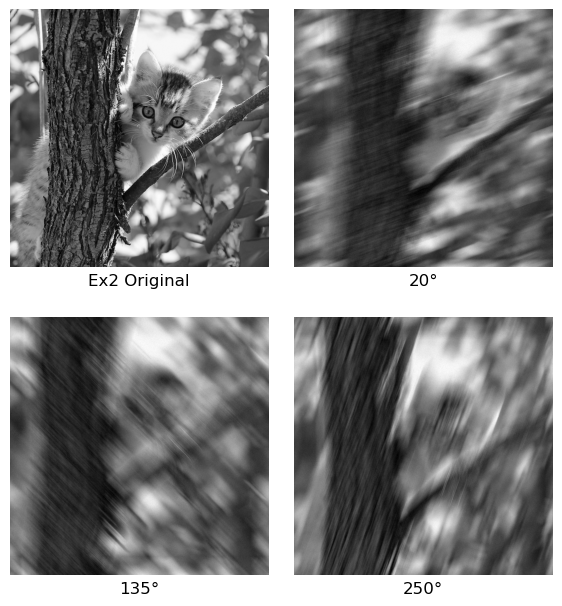

In [18]:
ex2_gray_arr = convert_img_to_norm_np_arr('./motion_deblur_img/input/Image_by_Pavel_from_Pixabay.jpg',
                                          grayscale=True)
length = 50
ex2_20_blurred = compute_linear_motion_blur(length, 20, ex2_gray_arr)
ex2_135_blurred = compute_linear_motion_blur(length, 135, ex2_gray_arr)
ex2_250_blurred = compute_linear_motion_blur(length, 250, ex2_gray_arr)

plot_comparison([ex2_gray_arr, ex2_20_blurred, ex2_135_blurred, ex2_250_blurred],
          ['Ex2 Original', '20°', '135°', '250°'],
          2, 2, figsize=(7, 8), cmap='gray')

----------
### Deblur Method Comparison with Angled Linear Motion Blurred Images
#### TSVD and Tikhonov for the 20° Example

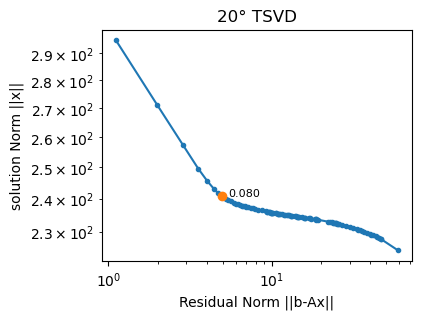

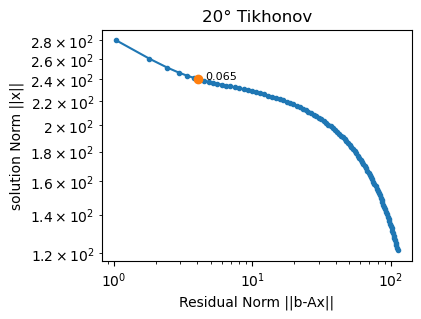

In [19]:
ex2_20_tsvd_tol = 0.08
ex2_20_tikhonov_alpha = 0.065
plot_l_curve_linear_motion(compute_tsvd, length, 20, ex2_20_blurred, 0.01, 0.95, '20° TSVD', [ex2_20_tsvd_tol])
plot_l_curve_linear_motion(compute_tikhonov, length, 20, ex2_20_blurred, 0.01, 0.95, '20° Tikhonov', [ex2_20_tikhonov_alpha])

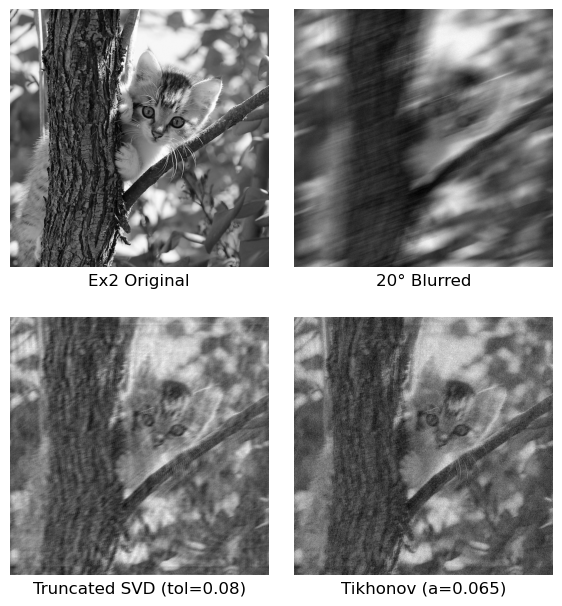

In [20]:
ex2_20_tsvd = compute_linear_motion_deblur(compute_tsvd, length, 20, ex2_20_blurred, 0.08)
ex2_20_tikhonov = compute_linear_motion_deblur(compute_tikhonov, length, 20, ex2_20_blurred, 0.065)

plot_comparison([ex2_gray_arr, ex2_20_blurred, ex2_20_tsvd, ex2_20_tikhonov],
          ['Ex2 Original', '20° Blurred', f'Truncated SVD (tol={ex2_20_tsvd_tol})', f'Tikhonov (a={ex2_20_tikhonov_alpha})'],
          2, 2, figsize=(7, 8), cmap='gray')

save_img(ex2_20_blurred, 'ex2_20deg_blurred.jpg', grayscale=True)
save_img(ex2_20_tikhonov, 'ex2_20deg_tikhonov.jpg', grayscale=True)

#### TSVD and Tikhonov for the 135° Example

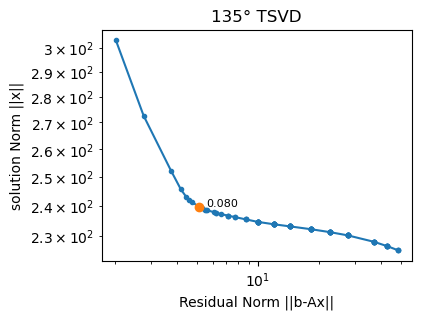

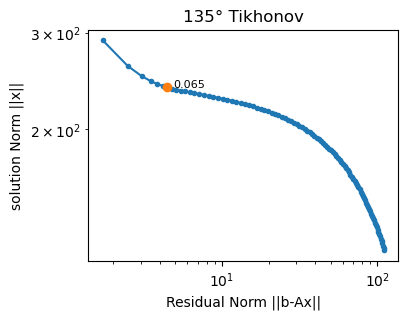

In [21]:
ex2_135_tsvd_tol = 0.08
ex2_135_tikhonov_alpha = 0.065
plot_l_curve_linear_motion(compute_tsvd, length, 135, ex2_135_blurred, 0.01, 0.95, '135° TSVD', [ex2_135_tsvd_tol])
plot_l_curve_linear_motion(compute_tikhonov, length, 135, ex2_135_blurred, 0.01, 0.95, '135° Tikhonov', [ex2_135_tikhonov_alpha])

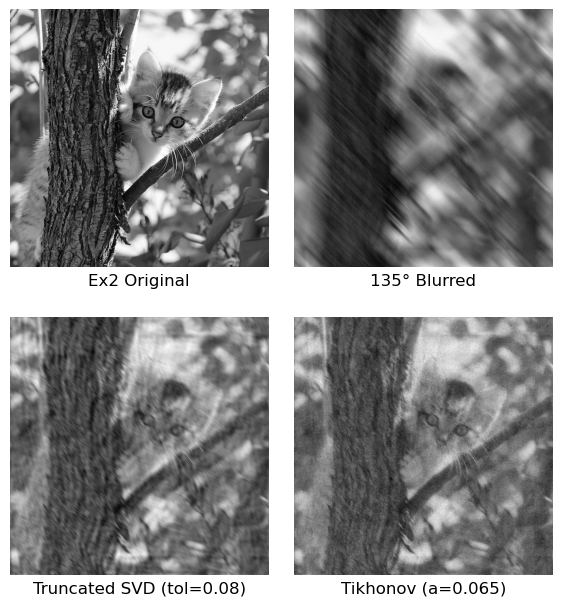

In [22]:
ex2_135_tsvd = compute_linear_motion_deblur(compute_tsvd, length, 135, ex2_135_blurred, 0.08)
ex2_135_tikhonov = compute_linear_motion_deblur(compute_tikhonov, length, 135, ex2_135_blurred, 0.065)

plot_comparison([ex2_gray_arr, ex2_135_blurred, ex2_135_tsvd, ex2_135_tikhonov],
          ['Ex2 Original', '135° Blurred', f'Truncated SVD (tol={ex2_135_tsvd_tol})', f'Tikhonov (a={ex2_135_tikhonov_alpha})'],
          2, 2, figsize=(7, 8), cmap='gray')

save_img(ex2_135_blurred, 'ex2_135deg_blurred.jpg', grayscale=True)
save_img(ex2_135_tikhonov, 'ex2_135deg_tikhonov.jpg', grayscale=True)

#### TSVD and Tikhonov for the 250° Example

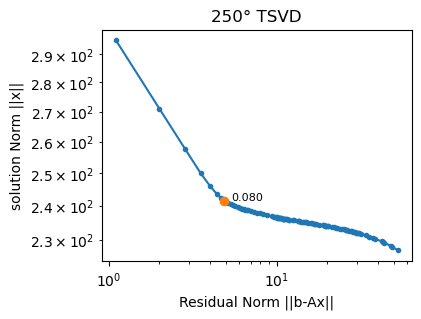

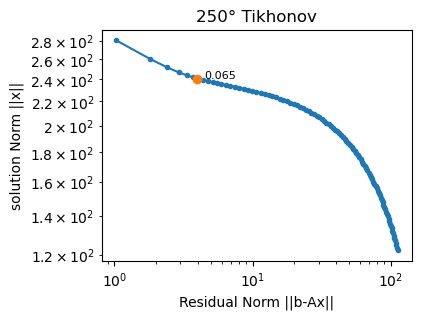

In [23]:
ex2_250_tsvd_tol = 0.08
ex2_250_tikhonov_alpha = 0.065
plot_l_curve_linear_motion(compute_tsvd, length, 250, ex2_250_blurred, 0.01, 0.95, '250° TSVD', [ex2_250_tsvd_tol])
plot_l_curve_linear_motion(compute_tikhonov, length, 250, ex2_250_blurred, 0.01, 0.95, '250° Tikhonov', [ex2_250_tikhonov_alpha])

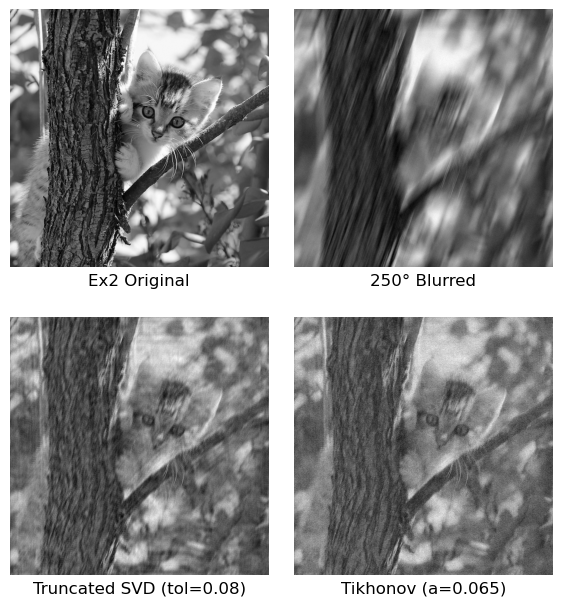

In [24]:
ex2_250_tsvd = compute_linear_motion_deblur(compute_tsvd, length, 250, ex2_250_blurred, 0.08)
ex2_250_tikhonov = compute_linear_motion_deblur(compute_tikhonov, length, 250, ex2_250_blurred, 0.065)

plot_comparison([ex2_gray_arr, ex2_250_blurred, ex2_250_tsvd, ex2_250_tikhonov],
          ['Ex2 Original', '250° Blurred', f'Truncated SVD (tol={ex2_250_tsvd_tol})', f'Tikhonov (a={ex2_250_tikhonov_alpha})'],
          2, 2, figsize=(7, 8), cmap='gray')

save_img(ex2_250_blurred, 'ex2_250deg_blurred.jpg', grayscale=True)
save_img(ex2_250_tikhonov, 'ex2_250deg_tikhonov.jpg', grayscale=True)

----------
----------
## Example 3
### Tikhonov Deblurring a Real Motion Blurred Photo with an Estimated PSF

----------
### [Test 1]
> Image Credit: [Marco Hofmann from Pixabay](https://pixabay.com/photos/tram-black-and-white-city-5451176/)

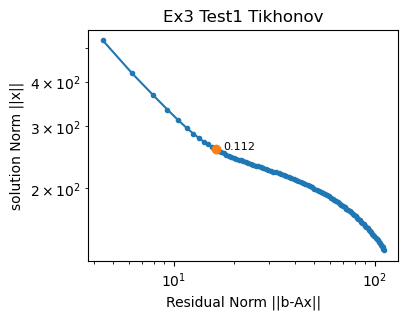

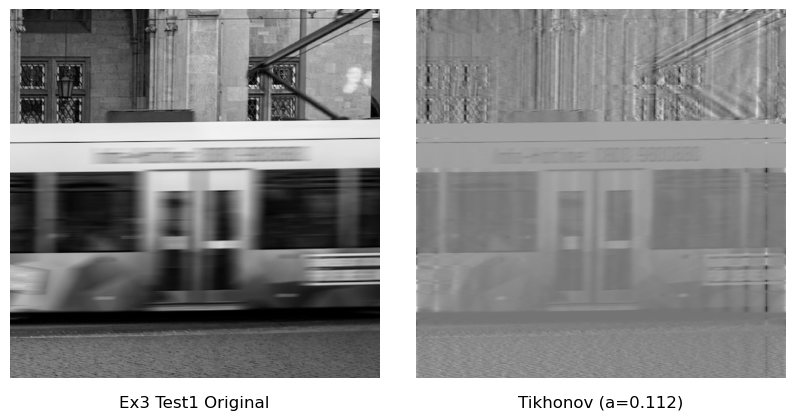

In [25]:
ex3_test1_gray = convert_img_to_norm_np_arr('./motion_deblur_img/input/Image_by_Marco_Hofmann_from_Pixabay.jpg',
                                          grayscale=True)

ex3_test1_estimated_length = 27
ex3_test1_estimated_angle = 1
ex3_test1_alpha = 0.112
plot_l_curve_linear_motion(compute_tikhonov, ex3_test1_estimated_length, ex3_test1_estimated_angle, 
                           ex3_test1_gray, 0.01, 0.9, 'Ex3 Test1 Tikhonov', [ex3_test1_alpha])

ex3_test1_tikhonov = compute_linear_motion_deblur(compute_tikhonov, ex3_test1_estimated_length, ex3_test1_estimated_angle, 
                                            ex3_test1_gray, ex3_test1_alpha)

plot_comparison([ex3_test1_gray, ex3_test1_tikhonov],
          ['Ex3 Test1 Original', f'Tikhonov (a={ex3_test1_alpha})'],
          1, 2, figsize=(10, 5), cmap='gray')

save_img(ex3_test1_gray, 'ex3_test1_gray.jpg', grayscale=True)
save_img(ex3_test1_tikhonov, 'ex3_test1_tikhonov.jpg', grayscale=True)

----------
### [Test 2]
> Image credit: Photo taken by the author.

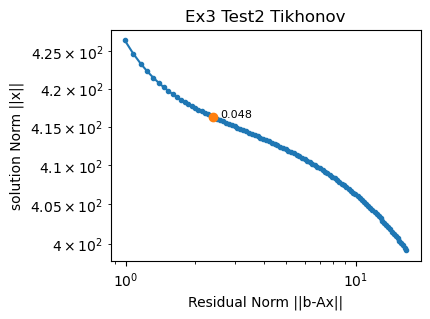

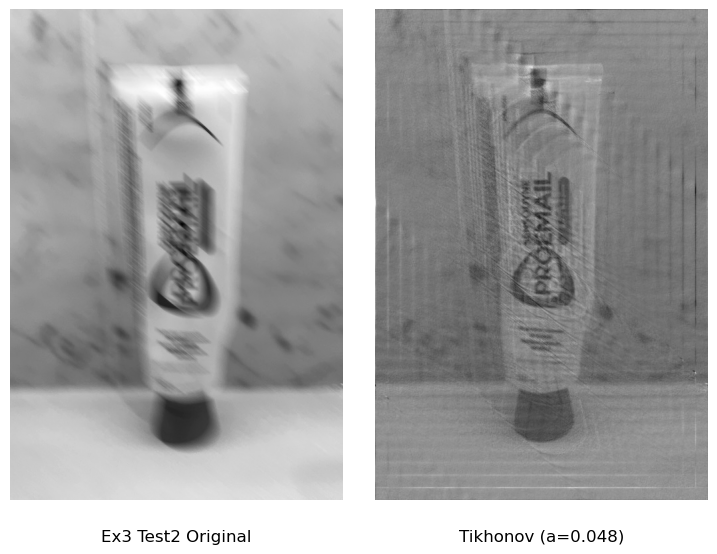

In [26]:
ex3_test2_gray = convert_img_to_norm_np_arr('./motion_deblur_img/input/toothpaste.jpg',
                                                grayscale=True)

ex3_test2_estimated_length = 26
ex3_test2_estimated_angle = 315
ex3_test2_alpha = 0.048
plot_l_curve_linear_motion(compute_tikhonov, ex3_test2_estimated_length, ex3_test2_estimated_angle, 
                           ex3_test2_gray, 0.01, 0.2, 'Ex3 Test2 Tikhonov', [ex3_test2_alpha])

ex3_test2_tikhonov = compute_linear_motion_deblur(compute_tikhonov, ex3_test2_estimated_length, ex3_test2_estimated_angle, 
                                            ex3_test2_gray, ex3_test2_alpha)

plot_comparison([ex3_test2_gray, ex3_test2_tikhonov],
          ['Ex3 Test2 Original', f'Tikhonov (a={ex3_test2_alpha})'],
          1, 2, figsize=(9, 7), cmap='gray')

save_img(ex3_test2_gray, 'ex3_test2_gray.jpg', grayscale=True)
save_img(ex3_test2_tikhonov, 'ex3_test2_tikhonov.jpg', grayscale=True)

----------
### [Test 3] Compare Different Alpha Values
> Image credit: Screenshot from "Photographing Motion with Camera Panning" by Mango Street, YouTube. https://youtu.be/rY-Dc3VnkT8?si=MhKkvIJT7LbU5D6Y&t=34

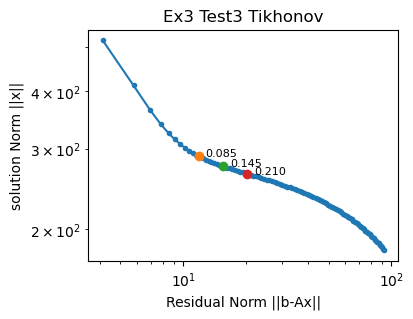

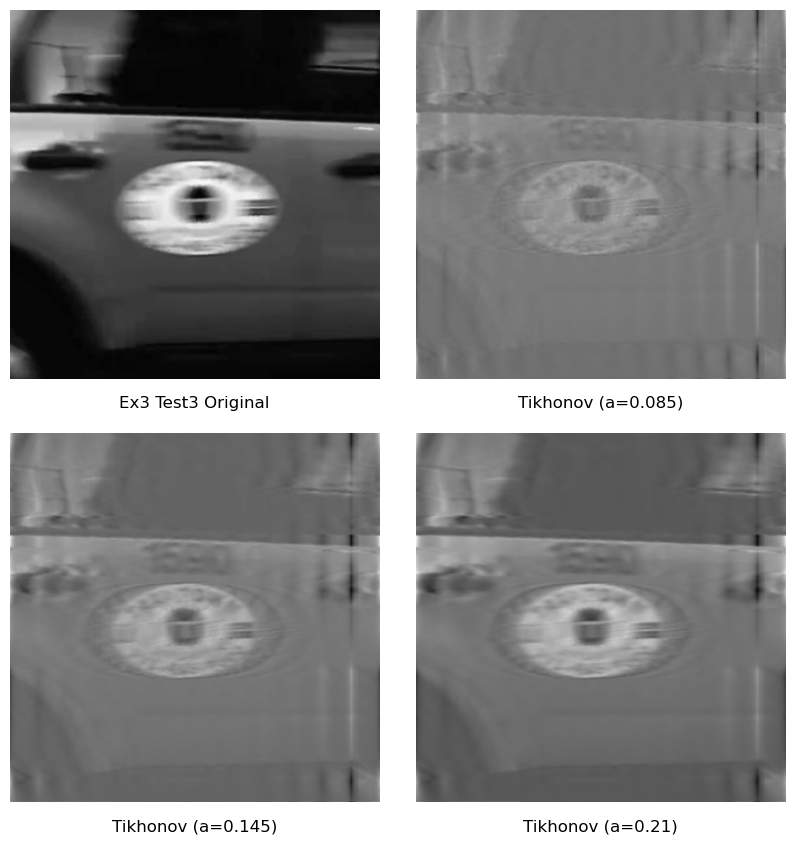

In [27]:
ex3_test3_gray = convert_img_to_norm_np_arr('./motion_deblur_img/input/screenshot_Mango_Street_Video.png',
                                            grayscale=True)
save_img(ex3_test3_gray, 'ex3_test3_gray.jpg', grayscale=True)

ex3_test3_estimated_length = 115
ex3_test3_estimated_angle = -1
ex3_test3_alphas = [0.085, 0.145, 0.210]
ex3_test3_tikhonov_results = []

plot_l_curve_linear_motion(compute_tikhonov, ex3_test3_estimated_length, ex3_test3_estimated_angle, 
                           ex3_test3_gray, 0.01, 0.7, 'Ex3 Test3 Tikhonov', ex3_test3_alphas)
for alpha in ex3_test3_alphas:
    ex3_test3_tikhonov = compute_linear_motion_deblur(compute_tikhonov, 
                                                      ex3_test3_estimated_length, ex3_test3_estimated_angle, 
                                                      ex3_test3_gray, alpha)
    ex3_test3_tikhonov_results.append(ex3_test3_tikhonov)
    save_img(ex3_test3_tikhonov, f'ex3_test3_tikhonov_{alpha}.jpg', grayscale=True)

plot_comparison(([ex3_test3_gray] + ex3_test3_tikhonov_results),
          ['Ex3 Test3 Original'] + [f'Tikhonov (a={alpha})' for alpha in ex3_test3_alphas],
          2, 2, figsize=(10, 11), cmap='gray')